# combining photometry data

In [1]:
import pandas as pd
import numpy as np

# ── Load the three band catalogues ────────────────────────────────────────────
df_v = pd.read_csv("maglist_V_catalog.csv")
df_b = pd.read_csv("maglist_B_catalog.csv")
df_r = pd.read_csv("maglist_R_catalog.csv")

# ── Merge on pixel position ───────────────────────────────────────────────────
# Use x and y as the common key — round to 2 decimal places to handle
# any tiny floating point differences between runs
df_v["x"] = df_v["x"].round(2)
df_v["y"] = df_v["y"].round(2)
df_b["x"] = df_b["x"].round(2)
df_b["y"] = df_b["y"].round(2)
df_r["x"] = df_r["x"].round(2)
df_r["y"] = df_r["y"].round(2)

df = df_v[["x", "y", "V_mag"]].merge(
        df_b[["x", "y", "B_mag"]],
        on=["x", "y"], how="inner"
     ).merge(
        df_r[["x", "y", "R_mag"]],
        on=["x", "y"], how="inner"
     )

print(f"Sources matched across all three bands: {len(df)}")

# ── Compute colours ───────────────────────────────────────────────────────────
df["B-V"] = df["B_mag"] - df["V_mag"]
df["V-R"] = df["V_mag"] - df["R_mag"]

# ── Reorder columns ───────────────────────────────────────────────────────────
df = df[["x", "y", "B_mag", "V_mag", "R_mag", "B-V", "V-R"]]

# ── Remove rows where any magnitude is NaN ────────────────────────────────────
df = df.dropna(subset=["B_mag", "V_mag", "R_mag"])
print(f"Sources with valid magnitudes in all bands: {len(df)}")

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv("NGC2547_BVR_catalog.csv", index=False)
print("\nCSV saved as NGC2547_BVR_catalog.csv")
print(df.head(10).to_string(index=False))

Sources matched across all three bands: 0
Sources with valid magnitudes in all bands: 0

CSV saved as NGC2547_BVR_catalog.csv
Empty DataFrame
Columns: [x, y, B_mag, V_mag, R_mag, B-V, V-R]
Index: []


In [2]:
import pandas as pd
import numpy as np

# ── Load the three band catalogues ────────────────────────────────────────────
df_v = pd.read_csv("maglist_V_catalog.csv")
df_b = pd.read_csv("maglist_B_catalog.csv")
df_r = pd.read_csv("maglist_R_catalog.csv")

print(f"V catalogue rows: {len(df_v)}")
print(f"B catalogue rows: {len(df_b)}")
print(f"R catalogue rows: {len(df_r)}")

# ── Quick diagnosis: check if x/y columns are close ──────────────────────────
print("\nFirst 3 x positions in each catalogue:")
print(f"  V: {df_v['x'].values[:3]}")
print(f"  B: {df_b['x'].values[:3]}")
print(f"  R: {df_r['x'].values[:3]}")

V catalogue rows: 3112
B catalogue rows: 3111
R catalogue rows: 3110

First 3 x positions in each catalogue:
  V: [239.40679808 632.06505762 764.98672585]
  B: [239.44285609 632.00903082 764.93196937]
  R: [239.46811295 632.1662183  765.0468859 ]


In [3]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

# ── Load catalogues ───────────────────────────────────────────────────────────
df_v = pd.read_csv("maglist_V_catalog.csv")
df_b = pd.read_csv("maglist_B_catalog.csv")
df_r = pd.read_csv("maglist_R_catalog.csv")

# ── Load WCS for each band to convert pixel → sky ─────────────────────────────
from astropy.wcs import WCS
from astropy.io import fits

with fits.open('g_NGC_2547_med.fits') as hdul:
    w_v = WCS(hdul[0].header)
with fits.open('b_NGC_2547_med.fits') as hdul:
    w_b = WCS(hdul[0].header)
with fits.open('r_NGC_2547_med.fits') as hdul:
    w_r = WCS(hdul[0].header)

# ── Convert pixel positions to sky coordinates ────────────────────────────────
def pix_to_skycoord(df, wcs):
    sky = wcs.pixel_to_world(df["x"].values, df["y"].values)
    return SkyCoord(ra=sky.ra, dec=sky.dec, frame='icrs')

coords_v = pix_to_skycoord(df_v, w_v)
coords_b = pix_to_skycoord(df_b, w_b)
coords_r = pix_to_skycoord(df_r, w_r)

# ── Match B → V within 1 arcsecond tolerance ─────────────────────────────────
idx_b, sep_b, _ = coords_v.match_to_catalog_sky(coords_b)
match_b = sep_b < 1.0 * u.arcsec

# ── Match R → V within 1 arcsecond tolerance ─────────────────────────────────
idx_r, sep_r, _ = coords_v.match_to_catalog_sky(coords_r)
match_r = sep_r < 1.0 * u.arcsec

# ── Build combined catalogue ──────────────────────────────────────────────────
df_combined = pd.DataFrame({
    "ra":    coords_v.ra.deg,
    "dec":   coords_v.dec.deg,
    "x_v":   df_v["x"].values,
    "y_v":   df_v["y"].values,
    "V_mag": df_v["V_mag"].values,
    "B_mag": np.where(match_b, df_b["B_mag"].values[idx_b], np.nan),
    "R_mag": np.where(match_r, df_r["R_mag"].values[idx_r], np.nan),
})

print(f"Total V sources:              {len(df_combined)}")
print(f"Matched B sources (<1 arcsec): {match_b.sum()}")
print(f"Matched R sources (<1 arcsec): {match_r.sum()}")

# ── Compute colours ───────────────────────────────────────────────────────────
df_combined["B-V"] = df_combined["B_mag"] - df_combined["V_mag"]
df_combined["V-R"] = df_combined["V_mag"] - df_combined["R_mag"]

# ── Keep only sources with all three bands ────────────────────────────────────
df_clean = df_combined.dropna(subset=["B_mag", "V_mag", "R_mag"])
print(f"Sources with all three bands:  {len(df_clean)}")

# ── Reorder and save ──────────────────────────────────────────────────────────
df_clean = df_clean[["ra", "dec", "x_v", "y_v", "B_mag", "V_mag", "R_mag", "B-V", "V-R"]]
df_clean.to_csv("NGC2547_BVR_catalog.csv", index=False)
print("\nSaved as NGC2547_BVR_catalog.csv")
print(df_clean.head(10).to_string(index=False))

Total V sources:              3112
Matched B sources (<1 arcsec): 2611
Matched R sources (<1 arcsec): 2626
Sources with all three bands:  1991

Saved as NGC2547_BVR_catalog.csv
        ra        dec         x_v       y_v     B_mag     V_mag     R_mag      B-V       V-R
122.462238 -48.507346  239.406798  2.940614 12.805953 12.252209 12.292994 0.553745 -0.040786
122.107984 -48.616514  632.065058  1.267509 12.857598 11.564399 11.024687 1.293199  0.539712
122.047689 -48.638887  701.267048  6.413906 14.377227 13.210662 12.729620 1.166565  0.481042
122.609979 -48.465555   77.895238  9.394762 13.505106 12.874738 12.619465 0.630368  0.255272
122.166298 -48.605249  571.794141 10.616284 11.927977 10.920936 10.566167 1.007040  0.354769
122.528302 -48.491541  169.072520  9.735737 13.809095 13.303972 13.327109 0.505123 -0.023136
122.253350 -48.578358  475.307343 10.822252 13.706451 12.737758 12.557976 0.968693  0.179782
121.823755 -48.707913  949.066833  6.716579 14.958419 13.814173 13.010654 1.144

# HR diagram 

Dust corrections applied:
  E(B-V)  = 0.06
  A_V     = 0.186 mag  (V-band extinction)
  A_B     = 0.246 mag  (B-band extinction)
  Colour shift in B-V: 0.060 mag

Sources after filtering: 1914


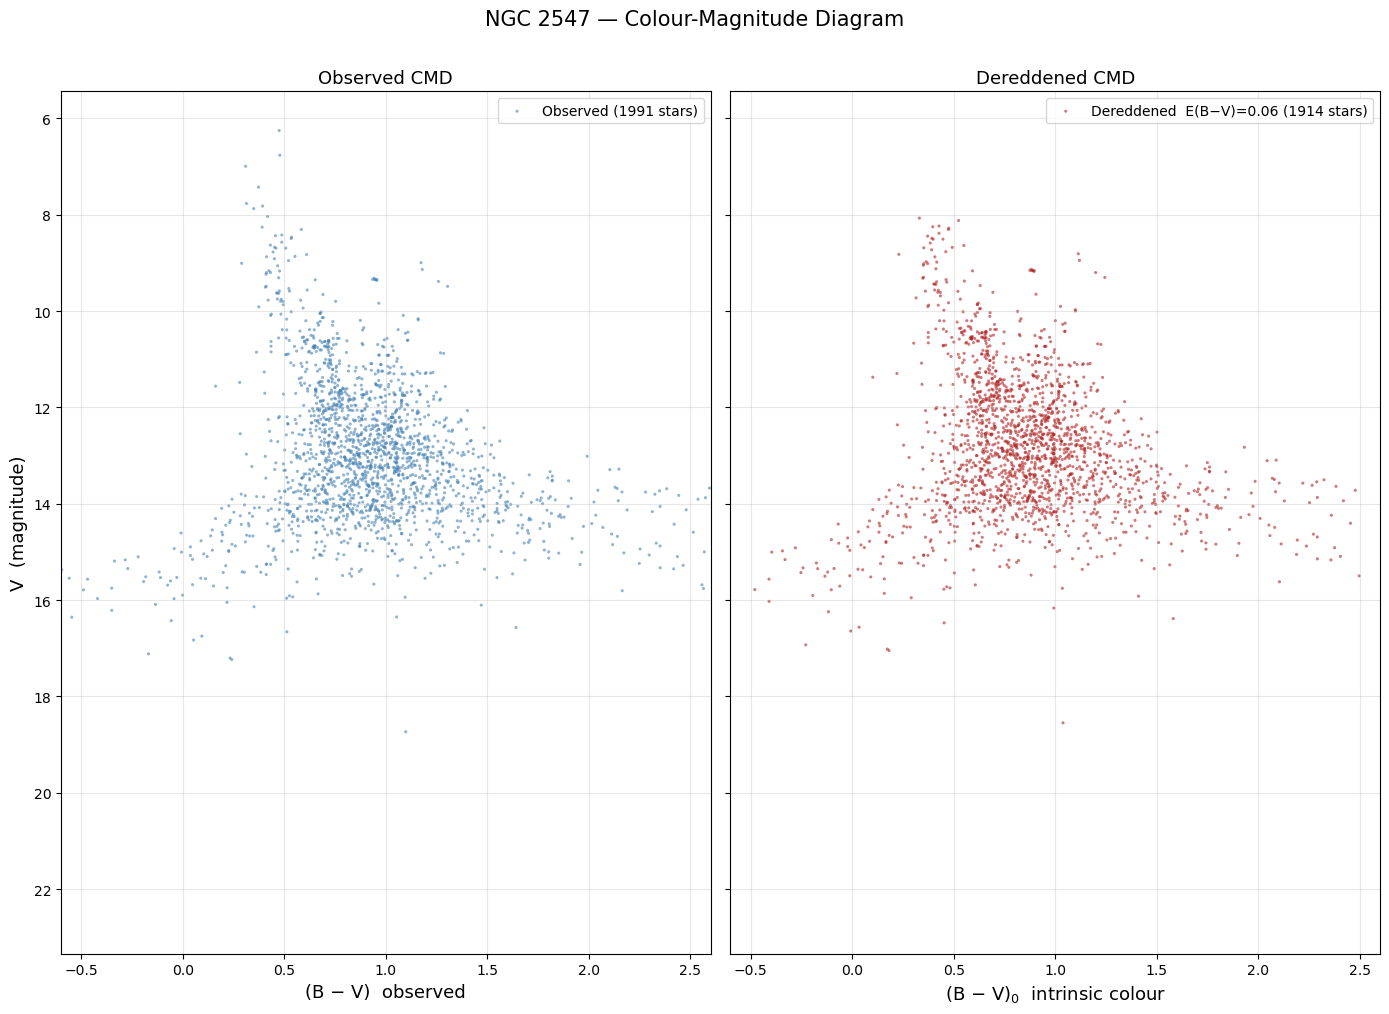

Saved as NGC2547_CMD_dereddened.png
Dereddened catalogue saved as NGC2547_BVR_dereddened.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load the combined catalogue ───────────────────────────────────────────────
df = pd.read_csv("NGC2547_BVR_catalog.csv")

# ── Dust correction ───────────────────────────────────────────────────────────
# NGC 2547 reddening from Claria (1982), confirmed by multiple studies
E_BV = 0.06

# Extinction in each band (from your lecture notes)
A_V = 3.1  * E_BV   # A_V ≈ 3.1 * E(B-V)
A_R = 3.8  * E_BV   # A_R ≈ 3.8 * E(V-R)  -- note: applied as 3.8*E(B-V)*scaling
A_B = A_V + E_BV    # A_B = A_V + E(B-V)  since E(B-V) = A_B - A_V

# Colour excess corrections
# E(B-V) is the shift in B-V colour due to dust
# So intrinsic (B-V)_0 = (B-V)_observed - E(B-V)
df["B-V_0"] = df["B-V"] - E_BV           # dereddened colour
df["V_0"]   = df["V_mag"] - A_V          # dereddened magnitude
df["V-R_0"] = df["V-R"] - (A_V - A_R)   # dereddened V-R colour

print(f"Dust corrections applied:")
print(f"  E(B-V)  = {E_BV:.2f}")
print(f"  A_V     = {A_V:.3f} mag  (V-band extinction)")
print(f"  A_B     = {A_B:.3f} mag  (B-band extinction)")
print(f"  Colour shift in B-V: {E_BV:.3f} mag")

# ── Filter to plausible values ────────────────────────────────────────────────
df_plot = df[
    (df["V_0"].between(8, 22)) &
    (df["B-V_0"].between(-0.5, 2.5))
].copy()

print(f"\nSources after filtering: {len(df_plot)}")

# ── Plot: observed vs dereddened side by side ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharey=True)

# Left panel: observed (uncorrected)
axes[0].scatter(
    df["B-V"],
    df["V_mag"],
    s=5, color="steelblue", alpha=0.6, edgecolors="none",
    label=f"Observed ({len(df)} stars)"
)
axes[0].invert_yaxis()
axes[0].set_xlabel("(B − V)  observed", fontsize=13)
axes[0].set_ylabel("V  (magnitude)", fontsize=13)
axes[0].set_title("Observed CMD", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right panel: dereddened
axes[1].scatter(
    df_plot["B-V_0"],
    df_plot["V_0"],
    s=5, color="firebrick", alpha=0.6, edgecolors="none",
    label=f"Dereddened  E(B−V)=0.06 ({len(df_plot)} stars)"
)
axes[1].set_xlabel("(B − V)$_0$  intrinsic colour", fontsize=13)
axes[1].set_title("Dereddened CMD", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Shared annotation
for ax in axes:
    ax.set_xlim(-0.6, 2.6)

fig.suptitle("NGC 2547 — Colour-Magnitude Diagram", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("NGC2547_CMD_dereddened.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as NGC2547_CMD_dereddened.png")

# ── Save dereddened catalogue ─────────────────────────────────────────────────
df_out = df[["ra", "dec", "x_v", "y_v",
             "B_mag", "V_mag", "R_mag",
             "B-V", "V-R",
             "B-V_0", "V_0", "V-R_0"]].copy()
df_out.to_csv("NGC2547_BVR_dereddened.csv", index=False)
print("Dereddened catalogue saved as NGC2547_BVR_dereddened.csv")

Distance modulus (intrinsic): 8.10
A_V:                          0.186
Apparent distance modulus:    8.286
Main sequence points:         40


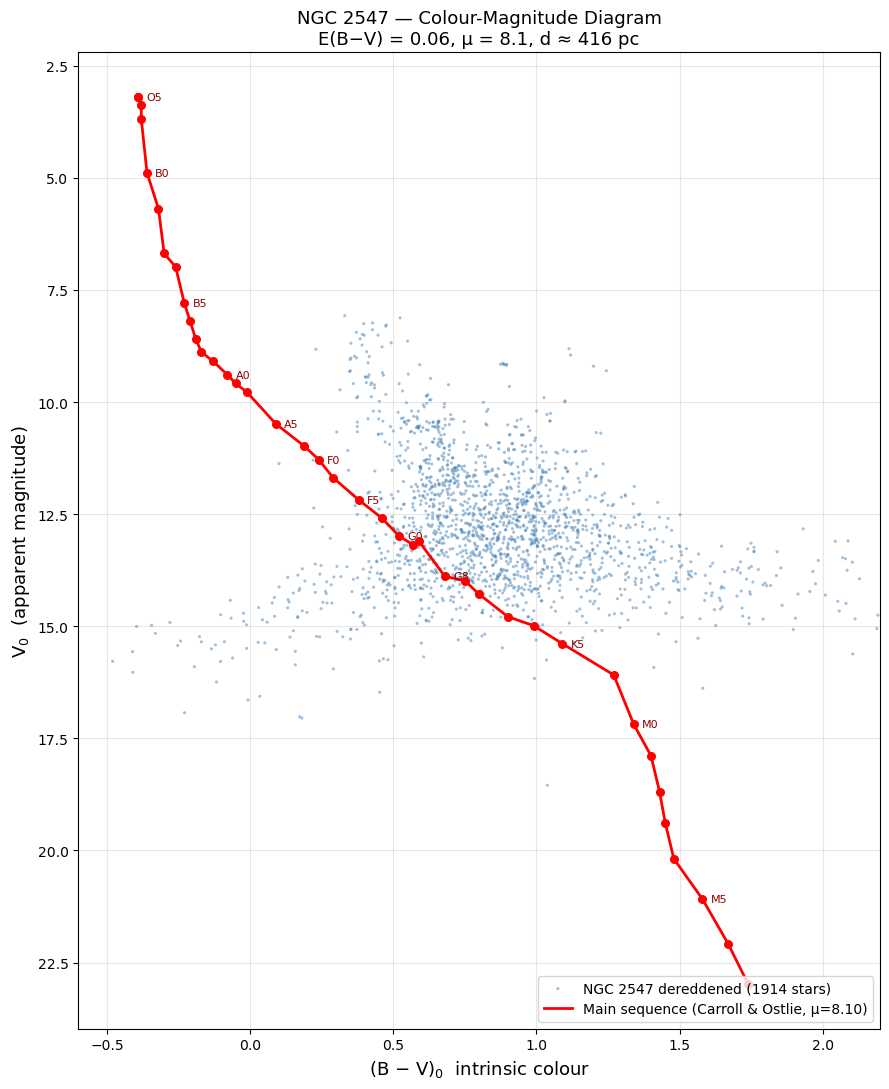

Saved as NGC2547_CMD_mainseq.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load NGC 2547 dereddened catalogue ────────────────────────────────────────
df = pd.read_csv("NGC2547_BVR_dereddened.csv")
df_plot = df[
    (df["V_0"].between(8, 22)) &
    (df["B-V_0"].between(-0.5, 2.5))
].copy()

# ── Load Carroll & Ostlie main sequence data ──────────────────────────────────
ms = pd.read_csv("CarrollOstlie_Apendix_StellarData.csv",
                 skipinitialspace=True)
ms.columns = ms.columns.str.strip()

# Clean up: replace '-' with NaN, convert to numeric
ms["MV"]  = pd.to_numeric(ms["MV"].astype(str).str.strip().str.replace("+", ""),
                           errors="coerce")
ms["B-V"] = pd.to_numeric(ms["B-V"].astype(str).str.strip().str.replace("+", ""),
                           errors="coerce")
ms = ms.dropna(subset=["MV", "B-V"])

# ── Convert absolute magnitude to apparent magnitude ─────────────────────────
# Using distance modulus for NGC 2547
# m - M = 5*log10(d/10pc)
# Literature: distance modulus μ = 8.1 (d ≈ 416 pc), E(B-V) = 0.06
E_BV        = 0.06
A_V         = 3.1 * E_BV          # = 0.186 mag
mu          = 8.10                 # intrinsic distance modulus
mu_apparent = mu + A_V             # apparent distance modulus = 8.286

ms["V_apparent"] = ms["MV"] + mu_apparent   # shift to apparent magnitude
ms["BV_0"]       = ms["B-V"] - E_BV         # deredden the main sequence colours

print(f"Distance modulus (intrinsic): {mu:.2f}")
print(f"A_V:                          {A_V:.3f}")
print(f"Apparent distance modulus:    {mu_apparent:.3f}")
print(f"Main sequence points:         {len(ms)}")

# ── Label positions for spectral types ───────────────────────────────────────
# Only label a selection to avoid crowding
label_types = ["O5", "B0", "B5", "A0", "A5", "F0", "F5", "G0", "G8", "K5", "M0", "M5"]
ms_labels   = ms[ms["Type"].isin(label_types)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 11))

# NGC 2547 stars
ax.scatter(
    df_plot["B-V_0"],
    df_plot["V_0"],
    s=5, color="steelblue", alpha=0.5, edgecolors="none", zorder=2,
    label=f"NGC 2547 dereddened ({len(df_plot)} stars)"
)

# Carroll & Ostlie main sequence
ax.plot(
    ms["BV_0"],
    ms["V_apparent"],
    color="red", linewidth=2, zorder=3,
    label=f"Main sequence (Carroll & Ostlie, μ={mu:.2f})"
)
ax.scatter(
    ms["BV_0"],
    ms["V_apparent"],
    color="red", s=30, zorder=4
)

# Spectral type labels
for _, row in ms_labels.iterrows():
    ax.annotate(
        row["Type"],
        xy=(row["BV_0"], row["V_apparent"]),
        xytext=(6, 0), textcoords="offset points",
        fontsize=8, color="darkred", va="center"
    )

# Formatting
ax.invert_yaxis()
ax.set_xlabel("(B − V)$_0$  intrinsic colour", fontsize=13)
ax.set_ylabel("V$_0$  (apparent magnitude)", fontsize=13)
ax.set_title("NGC 2547 — Colour-Magnitude Diagram\n"
             f"E(B−V) = {E_BV}, μ = {mu}, d ≈ 416 pc", fontsize=13)
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim(-0.6, 2.2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("NGC2547_CMD_mainseq.png", dpi=150)
plt.show()
print("Saved as NGC2547_CMD_mainseq.png")